# NLP02 — Transformer 챗봇 프로젝트

Ch.17 번역기와 동일한 Transformer 구조로 한국어 질문→답변 챗봇을 학습합니다.
- PyTorch + MPS(Mac) / CUDA
- 형태소 분석: `kiwipiepy` (Mac 호환, MeCab 대체)
- Augmentation: Kyubyong `ko.bin` Word2Vec

In [1]:
# ================================================================================
# 🎯 [Step 0. 환경 초기화 및 전역 상수 정의]
# - 목적: 재현 가능한 실험 환경을 구축하고, 이후 모든 셀에서 공유할 경로·하이퍼파라미터를 선언합니다.
# ================================================================================
import math
import random
import re
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt  # Step 6-C loss 곡선 시각화
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from gensim import utils
from gensim.models import KeyedVectors
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# === 하이퍼파라미터 / 상수 ===
SEED = 42              # 난수 시드: train/val 분리·증강·학습 초기화를 동일 조건으로 고정
MAX_LEN = 40           # 시퀀스 최대 길이: 질문·답변 토큰 수 상한 (패딩 기준)
MIN_TOKEN_LEN = 2      # 너무 짧은 문장(노이즈) 필터링 임계값
VAL_RATIO = 0.1        # 검증셋 비율 10%: 과적합 모니터링용 hold-out
LABEL_SMOOTHING = 0.1  # 정답 토큰 100% 신뢰 대신 0.9만 주어 과적합 완화
BEAM_SIZE = 8          # 5→8: Beam Search 폭 확대
BEAM_LENGTH_PENALTY = 0.8  # 0.7→0.8: 짧은 만능 답변 편향 완화

# === 증강·평가 실험 설정 (2차 개선) ===
USE_AUGMENTATION = False   # False: 원본 train만 (권장) / True: Word2Vec 증강
AUGMENT_MODE = "3x"        # "2x": 원본+질문치환 / "3x": 원본+질문+답변 치환
BLEU_EVAL_MAX = None       # None: val 전체(762건, beam=8 기준 ~44분) / 100: 빠른 실험(~3분)

# LMS 제출용 예문 4개 (학습 중·제출 시 공통 사용)
TEST_QUESTIONS = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

# 1. 파이썬·NumPy·PyTorch 난수 생성기를 동일 시드로 동기화 → 실험 재현성 확보
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 2. 연산 디바이스 자동 선택: Mac MPS → NVIDIA CUDA → CPU 순으로 우선 탐색
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
# 3. Apple Silicon 등에서 float32 행렬 곱 정밀도·속도 트레이드오프 조정 (가능할 때만)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# 4. 프로젝트 데이터·체크포인트 경로 정의 및 디렉터리 자동 생성
DATA_DIR = Path("./data")
CHATBOT_DIR = DATA_DIR / "chatbot"       # ChatbotData.csv, best_model.pt 저장 위치
EMBEDDINGS_DIR = DATA_DIR / "embeddings" # ko.bin Word2Vec 사전 위치
CHATBOT_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHATBOT_DIR / "best_model.pt"  # val loss 최저 시점 가중치 저장 경로

print("torch:", torch.__version__)
print("device:", device)


/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


torch: 2.8.0
device: mps


## Step 1. 데이터 다운로드

In [2]:
# ================================================================================
# 🎯 [Step 1. 챗봇 원본 코퍼스 수집]
# - 목적: songys/Chatbot_data 저장소에서 한국어 Q&A 쌍 CSV를 로컬로 확보합니다.
# ================================================================================
CHATBOT_CSV = CHATBOT_DIR / "ChatbotData.csv"
CHATBOT_URL = (
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData%20.csv"
)

# 1. 로컬에 CSV가 없으면 urllib로 원격 다운로드 (이미 있으면 스킵)
if not CHATBOT_CSV.exists():
  print("ChatbotData.csv 다운로드 중...")
  urllib.request.urlretrieve(CHATBOT_URL, CHATBOT_CSV)

# 2. pandas로 Q(질문)·A(답변) 열을 문자열 리스트로 추출
df = pd.read_csv(CHATBOT_CSV)
questions = df["Q"].astype(str).tolist()
answers = df["A"].astype(str).tolist()

print("총 문장 쌍:", len(questions))
print("질문 예시:", questions[0])
print("답변 예시:", answers[0])


총 문장 쌍: 11823
질문 예시: 12시 땡!
답변 예시: 하루가 또 가네요.


## Step 2. 데이터 정제 — `preprocess_sentence()`

In [3]:
# ================================================================================
# 🎯 [Step 2. 문장 정제 — preprocess_sentence()]
# - 목적: 대소문자 통일, 불필요 문자 제거, 공백 정규화로 토큰화 품질을 높입니다.
# ================================================================================

def preprocess_sentence(sentence: str) -> str:
    """
    [문장 전처리 파이프라인]
    - 소문자화 → 허용 문자만 유지 → 연속 공백 압축 → 앞뒤 공백 제거
    """
    sentence = sentence.lower()
    # 한글(\uAC00-\uD7A3), 영문, 숫자, 주요 구두점(.,!?)만 남기고 나머지는 공백 치환
    sentence = re.sub(r"[^a-z0-9\uAC00-\uD7A3\s.,!?]", " ", sentence)
    # 2칸 이상 연속 공백을 1칸으로 압축
    sentence = re.sub(r" {2,}", " ", sentence)
    return sentence.strip()

# 전체 질문·답변 리스트에 일괄 적용
questions = [preprocess_sentence(q) for q in questions]
answers = [preprocess_sentence(a) for a in answers]
print("정제 후:", questions[0])


정제 후: 12시 땡!


## Step 3. 데이터 토큰화 — `build_corpus()`

In [4]:
# ================================================================================
# 🎯 [Step 3. 형태소 토큰화 및 train/val 분리]
# - 목적: kiwipiepy로 형태소 단위 토큰 시퀀스를 만들고, 검증용 10%를 분리합니다.
# ================================================================================
from kiwipiepy import Kiwi

# 1. Kiwi 형태소 분석기 싱글톤 인스턴스 (Mac에서 MeCab 대체)
_kiwi = Kiwi()


class Mecab:
    """KoNLPy Mecab API 호환 래퍼 (kiwipiepy 기반)"""

    def morphs(self, text: str):
        # tokenize → .form: 표층형(기본형) 문자열만 추출하여 리스트 반환
        return [t.form for t in _kiwi.tokenize(text)]


mecab = Mecab()


def build_corpus(src_sentences, tgt_sentences, tokenizer_fn):
    """
    [코퍼스 빌드 엔진]
    - 질문(src)·답변(tgt) 쌍을 토큰 리스트로 변환
    - (질문, 답변) 쌍이 완전히 같을 때만 중복 제거 — 같은 답·다른 질문은 유지
    """
    src_corpus, tgt_corpus, raw_questions = [], [], []
    seen_pairs = set()

    for src, tgt in tqdm(zip(src_sentences, tgt_sentences), total=len(src_sentences)):
        src = preprocess_sentence(src)
        tgt = preprocess_sentence(tgt)
        src_tokens = tokenizer_fn(src)
        tgt_tokens = tokenizer_fn(tgt)

        # 너무 짧거나 MAX_LEN 초과 시퀀스는 학습 노이즈로 간주하고 스킵
        if len(src_tokens) < MIN_TOKEN_LEN or len(tgt_tokens) < MIN_TOKEN_LEN:
            continue
        if len(src_tokens) > MAX_LEN or len(tgt_tokens) > MAX_LEN:
            continue

        pair_key = (tuple(src_tokens), tuple(tgt_tokens))
        if pair_key in seen_pairs:
            continue

        seen_pairs.add(pair_key)
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)
        raw_questions.append(src)  # BLEU 평가용 원문 질문 보존

    return src_corpus, tgt_corpus, raw_questions


def train_val_split(que, ans, raw, val_ratio=VAL_RATIO):
    """
    [무작위 train/val 분할]
    - 인덱스 셔플 후 앞 val_ratio 비율을 검증셋으로 분리
    """
    n = len(que)
    idx = np.arange(n)
    np.random.seed(SEED)
    np.random.shuffle(idx)
    val_n = max(1, int(n * val_ratio))  # 최소 1개는 val 보장

    val_set = set(idx[:val_n].tolist())
    que_tr, ans_tr, raw_tr = [], [], []
    que_va, ans_va, raw_va = [], [], []

    for i in range(n):
        if i in val_set:
            que_va.append(que[i])
            ans_va.append(ans[i])
            raw_va.append(raw[i])
        else:
            que_tr.append(que[i])
            ans_tr.append(ans[i])
            raw_tr.append(raw[i])

    return que_tr, ans_tr, raw_tr, que_va, ans_va, raw_va


# 코퍼스 구축 → 9:1 분할
que_corpus, ans_corpus, raw_questions = build_corpus(questions, answers, mecab.morphs)
print(f"코퍼스: CSV {len(questions)}쌍 → 학습용 {len(que_corpus)}쌍 (같은 답·다른 질문 유지)")
print(f"코퍼스: CSV {len(questions)}쌍 → 학습용 {len(que_corpus)}쌍 (같은 답·다른 질문 유지)")
que_train, ans_train, raw_train, que_val, ans_val, raw_val = train_val_split(
    que_corpus, ans_corpus, raw_questions
)

# Step 7 BLEU 평가에 사용할 검증셋 원문·정답 토큰 보관
eval_questions = raw_val
eval_references = ans_val

print("train:", len(que_train), "| val:", len(que_val))


100%|██████████| 11823/11823 [00:05<00:00, 2225.22it/s]

코퍼스: CSV 11823쌍 → 학습용 11646쌍 (같은 답·다른 질문 유지)
코퍼스: CSV 11823쌍 → 학습용 11646쌍 (같은 답·다른 질문 유지)
train: 10482 | val: 1164


## Step 4. Augmentation (Lexical Substitution, 선택)

> **2차 개선:** `USE_AUGMENTATION=False`(기본)면 ko.bin 로드·증강을 건너뜁니다.  
> 설정 변경 후 **Step 4부터 Step 5까지** 다시 실행한 뒤 학습하세요.

In [5]:
# ================================================================================
# 🎯 [Step 4. Lexical Substitution 증강 — 3배 데이터 확장]
# - 목적: Kyubyong ko.bin Word2Vec으로 유사어 치환, train set만 3배 확장 (val은 원본 유지)
# ================================================================================
KO_BIN = EMBEDDINGS_DIR / "ko.bin"
KO_BIN_URL = "https://drive.google.com/uc?export=download&id=0B0ZXk88koS2KbDhXdWg1Q2RydlU"


def load_ko_wv(path: Path):
    """
    [구형 ko.bin 로더] ★
    - ko.bin은 gensim 2.x(2016) 포맷 → gensim 4.x의 Word2Vec.load()와 호환 불가
    - utils.unpickle로 구조 복원 후 syn0/index2word → KeyedVectors로 재조립
    """
    model = utils.unpickle(str(path))
    if hasattr(model, "wv"):
        return model.wv
    kv = KeyedVectors(vector_size=model.syn0.shape[1])
    kv.add_vectors(model.index2word, model.syn0)
    return kv


# ko.bin은 USE_AUGMENTATION=True 일 때만 로드 (약 300MB, 수십 초)


def lexical_sub_tokens(tokens, word_vectors):
    """
    [단어 1개 유사어 치환]
    - 문장 내 사전에 있는 토큰 1개를 무작위 선택 → most_similar로 대체
    """
    valid = [t for t in tokens if t in word_vectors]
    if not valid:
        return None
    selected = random.choice(valid)
    similar = word_vectors.most_similar(selected, topn=1)[0][0]
    replaced = [similar if t == selected else t for t in tokens]
    if replaced == tokens:
        return None
    return replaced


def augment_corpus(que, ans, word_vectors, mode="3x"):
    """
    [증강 파이프라인]
    - mode='2x': 질문치환 + 원본
    - mode='3x': 질문치환 + 원본 + 답변치환 (LMS 기본)
    """
    aug_que_1, aug_ans_1 = [], []
    for q, a in tqdm(zip(que, ans), total=len(que), desc="aug Q"):
        q_new = lexical_sub_tokens(q, word_vectors)
        aug_que_1.append(q_new if q_new else q)
        aug_ans_1.append(a)

    aug_que_2, aug_ans_2 = [], []
    for q, a in tqdm(zip(que, ans), total=len(que), desc="aug A"):
        a_new = lexical_sub_tokens(a, word_vectors)
        aug_que_2.append(q)
        aug_ans_2.append(a_new if a_new else a)

    if mode == "2x":
        new_que = aug_que_1 + que
        new_ans = aug_ans_1 + ans
    else:
        new_que = aug_que_1 + que + aug_que_2
        new_ans = aug_ans_1 + ans + aug_ans_2
    return new_que, new_ans


# 검증셋은 증강하지 않음 → val BLEU/loss가 과적합을 신뢰성 있게 반영
if USE_AUGMENTATION:
    if not KO_BIN.exists():
        print("ko.bin 다운로드 중... (약 300MB)")
        urllib.request.urlretrieve(KO_BIN_URL, KO_BIN)
    wv = load_ko_wv(KO_BIN)
    print("ko.bin 단어 수:", len(wv))
    que_train, ans_train = augment_corpus(que_train, ans_train, wv, mode=AUGMENT_MODE)
    print(f"증강 모드: {AUGMENT_MODE} | train 크기: {len(que_train)}")
else:
    print(f"USE_AUGMENTATION=False → 증강 스킵 | train 크기: {len(que_train)} (원본)")


USE_AUGMENTATION=False → 증강 스킵 | train 크기: 10482 (원본)


## Step 5. 데이터 벡터화

In [6]:
# ================================================================================
# 🎯 [Step 5. 단어 사전 구축 및 정수 인덱스 텐서 변환]
# - 목적: 토큰 문자열 → 정수 ID 매핑 후 (batch, MAX_LEN) LongTensor로 패딩
# ================================================================================

# 1. 특수 토큰 ID 고정: pad=0, start=1, end=2, unk=3 (이후 일반 단어는 4부터 부여)
PAD_ID, START_ID, END_ID, UNK_ID = 0, 1, 2, 3

# 2. 디코더(답변) 시퀀스 앞뒤에 <start>/<end> 토큰 삽입 (teacher forcing 학습용)
ans_train = [["<start>"] + a + ["<end>"] for a in ans_train]
ans_val = [["<start>"] + a + ["<end>"] for a in ans_val]

word2idx = {"<pad>": PAD_ID, "<start>": START_ID, "<end>": END_ID, "<unk>": UNK_ID}


def add_to_vocab(tokens):
    """등장 순서대로 신규 토큰에 고유 정수 ID 부여"""
    for tok in tokens:
        if tok not in word2idx:
            word2idx[tok] = len(word2idx)


# train + val 전체 시퀀스를 스캔하여 vocabulary 구축
for seq in que_train + ans_train + que_val + ans_val:
    add_to_vocab(seq)

idx2word = {i: w for w, i in word2idx.items()}  # 역방향 사전 (추론 시 디코딩)
VOCAB_SIZE = len(word2idx)
print("VOCAB_SIZE:", VOCAB_SIZE)


def encode(tokens):
    """토큰 리스트 → 정수 ID 리스트 (미등록 단어는 UNK_ID)"""
    return [word2idx.get(t, UNK_ID) for t in tokens]


def pad_sequences(sequences, max_len=MAX_LEN, pad_value=PAD_ID):
    """
    [가변 길이 → 고정 길이 패딩]
    - max_len 초과 시 잘라내고, 부족하면 pad_value(0)로 우측 패딩
    - 반환: (N, max_len) torch.LongTensor
    """
    out = []
    for seq in sequences:
        seq = seq[:max_len]
        seq = seq + [pad_value] * (max_len - len(seq))
        out.append(seq)
    return torch.tensor(out, dtype=torch.long)


# 3. 인코더(질문)·디코더(답변) 텐서를 device(GPU/MPS)로 즉시 업로드
enc_train = pad_sequences([encode(q) for q in que_train], MAX_LEN).to(device)
dec_train = pad_sequences([encode(a) for a in ans_train], MAX_LEN).to(device)
enc_val = pad_sequences([encode(q) for q in que_val], MAX_LEN).to(device)
dec_val = pad_sequences([encode(a) for a in ans_val], MAX_LEN).to(device)

print("enc_train:", enc_train.shape)
print("enc_val:", enc_val.shape)


VOCAB_SIZE: 4972
enc_train: torch.Size([10482, 40])
enc_val: torch.Size([1164, 40])


## Transformer 모델 정의 (Pre-LN + final_norm)

In [7]:
# ================================================================================
# 🎯 [Transformer 모델 정의 — Pre-LN + final_norm]
# - 목적: Ch.17 번역기와 동일 구조. Encoder-Decoder + Multi-Head Attention Seq2Seq
# ================================================================================

def positional_encoding(pos_len, d_model):
    """
    [삼각함수 기반 절대 위치 인코딩 테이블]
    - 공식: PE(pos, 2i)=sin(pos/10000^(2i/d)), PE(pos, 2i+1)=cos(...)
    - 반환: (pos_len, d_model) numpy 배열
    """
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    table = np.array([[cal_angle(p, i) for i in range(d_model)] for p in range(pos_len)])
    table[:, 0::2] = np.sin(table[:, 0::2])  # 짝수 차원: sin
    table[:, 1::2] = np.cos(table[:, 1::2])  # 홀수 차원: cos
    return table


class MultiHeadAttention(nn.Module):
    """
    [멀티헤드 셀프/크로스 어텐션 코어]
    - Q,K,V 선형투영 → 헤드 분할 → Scaled Dot-Product → concat → 출력 투영
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.depth = d_model // num_heads  # 헤드당 차원 (d_model / n_heads)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # (batch, seq, d_model) → (batch, heads, seq, depth)
        b, s, _ = x.size()
        x = x.view(b, s, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        # (batch, heads, seq, depth) → (batch, seq, d_model)
        b, h, s, d = x.size()
        x = x.permute(0, 2, 1, 3).contiguous().view(b, s, h * d)
        return x

    def forward(self, q, k, v, mask=None):
        q, k, v = self.w_q(q), self.w_k(k), self.w_v(v)
        q, k, v = self.split_heads(q), self.split_heads(k), self.split_heads(v)
        # Attention score = QK^T / sqrt(d_k)
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores + (mask * -1e9)  # 마스크 위치는 -∞에 가깝게 → softmax 후 0
        attn = F.softmax(scores, dim=-1)
        out = self.combine_heads(torch.matmul(attn, v))
        return self.linear(out), attn


class FFN(nn.Module):
    """[Position-wise Feed-Forward] d_model → d_ff → d_model, ReLU 활성화"""
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class EncoderLayer(nn.Module):
    """
    [Pre-LN Encoder Layer] ★
    - Norm → Self-Attention → Residual → Norm → FFN → Residual
    (Post-LN과 달리 LayerNorm을 서브레이어 앞에 배치 → 학습 안정성 향상)
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FFN(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        residual = x
        x = self.norm1(x)
        x, attn = self.self_attn(x, x, x, mask)
        x = self.drop(x) + residual
        residual = x
        x = self.norm2(x)
        x = self.drop(self.ffn(x)) + residual
        return x, attn


class DecoderLayer(nn.Module):
    """
    [Pre-LN Decoder Layer]
    - Masked Self-Attention → Cross-Attention(enc_out) → FFN (각각 Residual)
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FFN(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        residual = x
        x = self.norm1(x)
        x, self_attn = self.self_attn(x, x, x, dec_mask)  # dec_mask: 미래 토큰 차단
        x = self.drop(x) + residual
        residual = x
        x = self.norm2(x)
        x, cross_attn = self.cross_attn(x, enc_out, enc_out, dec_enc_mask)
        x = self.drop(x) + residual
        residual = x
        x = self.norm3(x)
        x = self.drop(self.ffn(x)) + residual
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # 스택 출력 최종 정규화

    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return self.final_norm(x), attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, dec_enc_mask, dec_mask)
            self_attns.append(sa)
            cross_attns.append(ca)
        return self.final_norm(x), self_attns, cross_attns


class Transformer(nn.Module):
    """
    [Seq2Seq Transformer 챗봇 본체]
    - Embedding 공유: fc.weight = emb.weight (입력·출력 어휘 공간 동일)
    - pos_encoding: register_buffer로 고정 위치 벡터 등록 (역전파 대상 아님)
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.2):
        super().__init__()
        self.d_model = float(d_model)
        self.emb = nn.Embedding(vocab_size, d_model)
        self.pos = torch.tensor(positional_encoding(pos_len, d_model), dtype=torch.float32)
        self.register_buffer("pos_encoding", self.pos)  # save/load·device 이동 시 함께 이동
        self.drop = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, vocab_size)
        self.fc.weight = self.emb.weight  # Weight Tying: 파라미터 수 절감 + 성능 향상

    def embed(self, x):
        """토큰 ID → (임베딩 * sqrt(d_model)) + 위치인코딩 + Dropout"""
        s = x.size(1)
        out = self.emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:s].unsqueeze(0)
        return self.drop(out)

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_out, enc_attns = self.encoder(self.embed(enc_in), enc_mask)
        dec_out, dec_attns, cross_attns = self.decoder(self.embed(dec_in), enc_out, dec_enc_mask, dec_mask)
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns

print("모델 클래스 정의 완료")


모델 클래스 정의 완료


In [8]:
# ================================================================================
# 🎯 [학습 보조 함수 — 마스크, LR 스케줄러, 손실, train/eval step]
# ================================================================================
_lookahead_cache = {}  # 동일 (seq_len, device) 조합의 lookahead 마스크 재사용 캐시


def generate_padding_mask(seq):
    """
    [패딩 마스크 생성]
    - PAD_ID(0) 위치를 1.0, 실제 토큰을 0.0으로 표시 → attention에서 -1e9 가산
    - 반환 shape: (batch, 1, 1, seq_len) — 브로드캐스팅용
    """
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_masks(src, tgt):
    """
    [3종 마스크 동시 생성]
    - enc_mask: 인코더 패딩 마스크
    - dec_enc_mask: 디코더→인코더 cross-attn용 (인코더 패딩 위치 차단)
    - dec_mask: 디코더 self-attn용 (패딩 + 미래 토큰 lookahead 차단)
    """
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)
    size = tgt.size(1)
    key = (size, str(src.device))
    if key not in _lookahead_cache:
        # 상삼각 행렬: diagonal=1 위쪽이 1 → 현재 시점 이후 토큰 마스킹
        _lookahead_cache[key] = torch.triu(torch.ones(size, size, device=src.device), diagonal=1)
    lookahead = _lookahead_cache[key].unsqueeze(0).unsqueeze(1)
    dec_mask = torch.max(generate_padding_mask(tgt), lookahead)
    return enc_mask, dec_enc_mask, dec_mask


class LearningRateScheduler:
    """
    [Noam 스케줄러 — Attention Is All You Need]
    - lr(step) = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
    - warmup 구간: 선형 증가 / 이후: step^(-0.5) 역제곱근 감쇠
    """
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


def loss_function(real, pred):
    """
    [Cross-Entropy + Label Smoothing]
    - pred: (batch, seq, vocab) → (-1, vocab)로 평탄화
    - PAD_ID 위치는 ignore_index로 손실 계산 제외
    """
    return F.cross_entropy(
        pred.reshape(-1, pred.size(-1)),
        real.reshape(-1),
        ignore_index=PAD_ID,
        label_smoothing=LABEL_SMOOTHING,
    )


def train_step(src, tgt, model, optimizer, step, lr_scheduler):
    """단일 미니배치 순전파·역전파·가중치 갱신 1스텝"""
    model.train()
    optimizer.zero_grad(set_to_none=True)
    lr = lr_scheduler(step)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    # Teacher Forcing: 디코더 입력은 tgt[:-1], 정답(gold)은 tgt[1:] (1토큰 시프트)
    tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    pred, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, pred)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient explosion 방지
    optimizer.step()
    return loss.item()


@torch.inference_mode()
def eval_epoch(model, loader):
    """검증셋 평균 loss 계산 (역전파 없음)"""
    model.eval()
    total = 0.0
    for src, tgt in loader:
        tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
        pred, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        total += loss_function(gold, pred).item()
    return total / len(loader)


## Step 6. 훈련하기

> 실행 순서: **6-A 모델 초기화 → 6-B 추론 함수 → 6-C 학습 → 6-D 제출 출력**
> **6-C**에서 epoch별 진행 바·예문 답변·**loss 곡선 그래프**가 셀에 남습니다.


In [9]:
# ================================================================================
# 🎯 [Step 6-A. 하이퍼파라미터·모델·옵티마이저 초기화]
# - 챗봇 데이터(~7천 쌍)는 작아서 1-layer·dropout·Early Stopping으로 과적합 방지
# - val loss 최저 epoch 가중치만 CHECKPOINT_PATH에 저장. 데이터가 작아 dropout·Early Stopping으로 과적합 완화
# ================================================================================
N_LAYERS = 1       # Transformer 층 수 (소규모 데이터 → 1층이 과적합 덜함)
D_MODEL = 368        # 임베딩·어텐션 hidden 차원
N_HEADS = 8          # 멀티헤드 수 (D_MODEL % N_HEADS == 0 필수)
D_FF = 1024          # FFN 내부 확장 차원
DROPOUT = 0.2        # 드롭아웃 — 학습 시 뉴런 일부를 꺼 과적합 완화
BATCH_SIZE = 64      # 미니배치 크기
EPOCHS = 30          # 20→30: Early Stopping 여유 확대
WARMUP_STEPS = 2000  # 1000→2000: warmup 구간 확대
PATIENCE = 6         # 4→6: best model 탐색 여유
WEIGHT_DECAY = 0.01  # AdamW L2 정규화 계수

# Encoder-Decoder Transformer 생성 후 device(MPS/CUDA/CPU)로 이동
transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    vocab_size=VOCAB_SIZE,
    pos_len=MAX_LEN + 10,
    dropout=DROPOUT,
).to(device)

# DataLoader: (enc, dec) 텐서 쌍 배치 공급 — train shuffle / val 고정
train_loader = DataLoader(TensorDataset(enc_train, dec_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(enc_val, dec_val), batch_size=BATCH_SIZE)

lr_scheduler = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)
optimizer = torch.optim.AdamW(
    transformer.parameters(),
    lr=lr_scheduler(1),
    betas=(0.9, 0.98),   # Transformer 논문 기본값
    eps=1e-9,
    weight_decay=WEIGHT_DECAY,
)

print(f"train steps/epoch={len(train_loader)}, val steps/epoch={len(val_loader)}")


train steps/epoch=164, val steps/epoch=19


In [10]:
# ================================================================================
# 🎯 [Step 6-B. Beam Search 추론 함수 정의]
# - 학습 루프(epoch별 예문 미리보기)와 제출 셀에서 공통 사용
# ================================================================================

def decode_ids(ids):
    """정수 ID 리스트 → 공백 구분 문자열 (pad/start/end 특수 토큰 제외)"""
    words = []
    for i in ids:
        if i in (PAD_ID, START_ID):
            continue
        if i == END_ID:
            break
        words.append(idx2word.get(i, "<unk>"))
    return " ".join(words)


def _next_token_log_probs(model, src, seq):
    """현재까지 생성된 seq에 대한 다음 토큰 log 확률 분포 반환"""
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, seq)
    pred, _, _, _ = model(src, seq, enc_mask, dec_enc_mask, dec_mask)
    return F.log_softmax(pred[0, -1], dim=-1)


@torch.inference_mode()
def beam_search_chat(model, question, beam_size=BEAM_SIZE, max_len=MAX_LEN):
    """
    [Beam Search 디코딩 엔진]
    - 각 스텝마다 beam_size개 후보 유지, length penalty로 짧은 문장 편향 완화
    """
    model.eval()
    # 질문 전처리 → 형태소 분석 → word2idx 인코딩
    tokens = encode(mecab.morphs(preprocess_sentence(question)))
    src = pad_sequences([tokens], max_len).to(device)

    # beams: (누적 log 점수, 토큰 시퀀스) / completed: <end>로 끝난 후보
    beams = [(0.0, torch.tensor([[START_ID]], dtype=torch.long, device=device))]
    completed = []

    for _ in range(max_len):
        candidates = []
        for score, seq in beams:
            last_id = seq[0, -1].item()
            if last_id == END_ID:
                completed.append((score, seq))
                continue

            log_probs = _next_token_log_probs(model, src, seq)
            topk = torch.topk(log_probs, beam_size)
            length_penalty = ((5 + seq.size(1)) / 6) ** BEAM_LENGTH_PENALTY

            for i in range(beam_size):
                nid = topk.indices[i].item()
                if nid == PAD_ID:
                    continue
                new_score = score + topk.values[i].item() / length_penalty
                new_seq = torch.cat([seq, torch.tensor([[nid]], device=device)], dim=1)
                candidates.append((new_score, new_seq))

        if not candidates:
            break

        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_size]  # 상위 beam_size개만 유지

        if all(b[1][0, -1].item() == END_ID for b in beams):
            completed.extend(beams)
            break

    if completed:
        best = max(completed, key=lambda x: x[0])
    else:
        best = max(beams, key=lambda x: x[0])

    return decode_ids(best[1][0].tolist())


def chat(model, question: str):
    """외부 호출용 래퍼: 질문 문자열 → 답변 문자열"""
    return beam_search_chat(model, question)

print("추론 함수 준비 완료 (beam_search_chat, chat)")


추론 함수 준비 완료 (beam_search_chat, chat)


Epoch 1/30: 100%|██████████| 164/164 [00:14<00:00, 11.15it/s, loss=225.5163, lr=9.56e-05]


Epoch 1: train=312.8407, val=225.1252  *best*
--- 예문 답변 미리보기 ---
  Q: 지루하다, 놀러가고 싶어.
  A: 
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 
  Q: 집에 있는다는 소리야.
  A: 


Epoch 2/30: 100%|██████████| 164/164 [00:12<00:00, 13.18it/s, loss=28.4870, lr=1.91e-04]


Epoch 2: train=80.4910, val=26.4033  *best*
--- 예문 답변 미리보기 ---
  Q: 지루하다, 놀러가고 싶어.
  A: .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: .
  Q: 집에 있는다는 소리야.
  A: .


Epoch 3/30: 100%|██████████| 164/164 [00:12<00:00, 13.01it/s, loss=16.6590, lr=2.87e-04]


...

Epoch 28: train=3.4928, val=3.6910  *best*
--- 예문 답변 미리보기 ---
  Q: 지루하다, 놀러가고 싶어.
  A: 저 가 있 어요 .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 잘 하 었 어요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 말 하 어 보 세요 .
  Q: 집에 있는다는 소리야.
  A: 축하 하 어요 .


Epoch 29/30: 100%|██████████| 164/164 [00:12<00:00, 13.15it/s, loss=3.4194, lr=7.56e-04]


Epoch 29: train=3.4645, val=3.6834  *best*
--- 예문 답변 미리보기 ---
  Q: 지루하다, 놀러가고 싶어.
  A: 저 가 있 어요 .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 조심 하 세요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 말 하 어 보 세요 .
  Q: 집에 있는다는 소리야.
  A: 좋 은 것 같 어요 .


Epoch 30/30: 100%|██████████| 164/164 [00:12<00:00, 12.85it/s, loss=3.5434, lr=7.43e-04]


Epoch 30: train=3.4358, val=3.6855  (patience 1/6)
--- 예문 답변 미리보기 ---
  Q: 지루하다, 놀러가고 싶어.
  A: 저 랑 놀 어요 .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 조심 하 세요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 말 하 어 보 세요 .
  Q: 집에 있는다는 소리야.
  A: 축하 하 어요 .
Best val loss: 3.6834


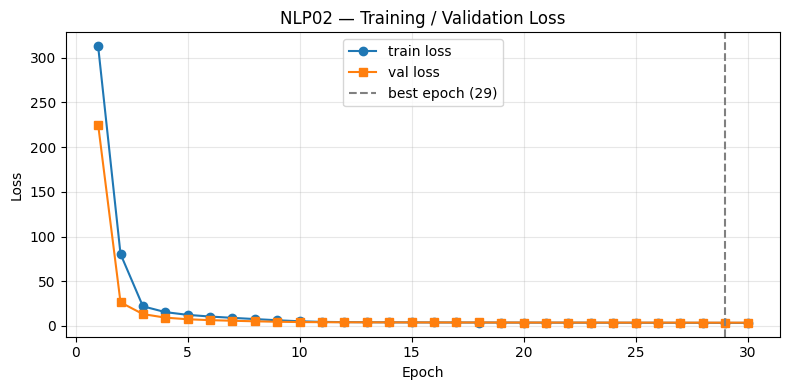

CPU times: user 5min 36s, sys: 1min 48s, total: 7min 24s
Wall time: 14min 23s


In [11]:
%%time
# ================================================================================
# 🎯 [Step 6-C. 훈련 루프 + Early Stopping + Best Model 저장]
# - 매 epoch train/val loss → best 저장 → 예문 미리보기 → loss 곡선 그래프
# ================================================================================

global_step = 0
best_val_loss = float("inf")   # 지금까지 최저 val loss
patience_counter = 0
history = []  # (train_loss, val_loss) epoch별 기록

for epoch in range(EPOCHS):
    # --- 1) Train: Teacher Forcing 배치 학습 ---
    transformer.train()
    train_loss = 0.0
    # leave=True: epoch 완료 후 진행 바를 셀 출력에 유지 (NLP03과 동일)
    bar = tqdm(total=len(train_loader), leave=True, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for src, tgt in train_loader:
        global_step += 1
        batch_loss = train_step(src, tgt, transformer, optimizer, global_step, lr_scheduler)
        train_loss += batch_loss
        bar.set_postfix(loss=f"{batch_loss:.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")
        bar.update(1)
    bar.close()

    # --- 2) Validation: 역전파 없이 val loss 측정 ---
    avg_train = train_loss / len(train_loader)
    avg_val = eval_epoch(transformer, val_loader)
    history.append((avg_train, avg_val))

    # --- 3) Early Stopping + 체크포인트 ---
    if avg_val < best_val_loss:
        # ★ 검증 손실 신기록 → patience 리셋 + 체크포인트 저장
        best_val_loss = avg_val
        patience_counter = 0
        torch.save({
            "model_state_dict": transformer.state_dict(),
            "epoch": epoch + 1,
            "val_loss": avg_val,
            "hyperparams": {
                "n_layers": N_LAYERS,
                "d_model": D_MODEL,
                "n_heads": N_HEADS,
                "d_ff": D_FF,
                "dropout": DROPOUT,
            },
        }, CHECKPOINT_PATH)
        tqdm.write(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}  *best*")
    else:
        patience_counter += 1
        tqdm.write(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}  (patience {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            tqdm.write("Early stopping 발동")
            break

    # --- 4) epoch마다 예문 4개 답변 미리보기 (NLP03과 동일 — 학습 진행 모니터링)
    tqdm.write("--- 예문 답변 미리보기 ---")
    for ex in TEST_QUESTIONS:
        tqdm.write(f"  Q: {ex}")
        tqdm.write(f"  A: {chat(transformer, ex)}")

tqdm.write(f"Best val loss: {best_val_loss:.4f}")

# --- 5) train/val loss 곡선 시각화 (PRT·제출 캡처용) ---
epochs_ran = list(range(1, len(history) + 1))
train_hist = [t for t, _ in history]
val_hist = [v for _, v in history]
best_epoch = int(np.argmin(val_hist)) + 1 if val_hist else 0

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, train_hist, "o-", label="train loss")
plt.plot(epochs_ran, val_hist, "s-", label="val loss")
if best_epoch:
    plt.axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NLP02 — Training / Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# ================================================================================
# 🎯 [Step 6-D. Best Model 로드 · LMS 제출용 출력]
# - best checkpoint 복원 후 예문 4개 + 하이퍼파라미터 블록 출력
# ================================================================================

# 6-C만 건너뛰고 실행 시 대비
history = globals().get("history", [])
best_val_loss = globals().get("best_val_loss", float("inf"))

# best model 로드: Early Stopping 시점의 최적 가중치 복원
if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    transformer.load_state_dict(ckpt["model_state_dict"])
    print(f"Best model loaded (epoch={ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

print("Translations")
for i, q in enumerate(TEST_QUESTIONS, 1):
    ans = chat(transformer, q)
    print(f"> {i}. {ans} <end>")

print("\nHyperparameters")
print(f"> n_layers: {N_LAYERS}")
print(f"> d_model: {D_MODEL}")
print(f"> n_heads: {N_HEADS}")
print(f"> d_ff: {D_FF}")
print(f"> dropout: {DROPOUT}")
print("\nTraining Parameters")
print(f"> Warmup Steps: {WARMUP_STEPS}")
print(f"> Batch Size: {BATCH_SIZE}")
print(f"> Epoch At: {len(history)}")
print(f"> Beam Size: {BEAM_SIZE}")
print(f"> Augmentation: {'on(' + AUGMENT_MODE + ')' if USE_AUGMENTATION else 'off'}")


Best model loaded (epoch=29, val_loss=3.6834)
Translations
> 1. 저 가 있 어요 . <end>
> 2. 조심 하 세요 . <end>
> 3. 말 하 어 보 세요 . <end>
> 4. 좋 은 것 같 어요 . <end>

Hyperparameters
> n_layers: 1
> d_model: 368
> n_heads: 8
> d_ff: 1024
> dropout: 0.2

Training Parameters
> Warmup Steps: 2000
> Batch Size: 64
> Epoch At: 30
> Beam Size: 8
> Augmentation: off


## Step 7. 성능 측정 (BLEU)

> `BLEU_EVAL_MAX=100`으로 바꾸면 **약 3분** 안에 빠른 평가 가능. 제출 전 `None`으로 전체 평가 (beam=8 기준 **~44분**).

In [13]:
# ================================================================================
# 🎯 [Step 7. BLEU Score 성능 측정]
# - 검증셋 BLEU: 모델 답변 vs 정답 형태소 n-gram 겹침 정도
# - BLEU_EVAL_MAX=100 → ~3분 / None → 762건 전체 (beam=8 기준 ~44분)
# ================================================================================

def calculate_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25)):
    """
    [문장 단위 BLEU]
    - reference: 정답 형태소 토큰 리스트
    - candidate: 모델 생성 답변 토큰 리스트
    - 1~4-gram 각 25% 가중 평균, smoothing으로 짧은 문장 0점 방지
    """
    return sentence_bleu(
        [reference],
        candidate,
        weights=weights,
        smoothing_function=SmoothingFunction().method1,
    )


# 평가 대상 선택 (전체 or 샘플)
bleu_eval_q = eval_questions
bleu_eval_r = eval_references
if BLEU_EVAL_MAX is not None:
    bleu_eval_q = eval_questions[:BLEU_EVAL_MAX]
    bleu_eval_r = eval_references[:BLEU_EVAL_MAX]
    print(f"BLEU 빠른 평가: {len(bleu_eval_q)}/{len(eval_questions)}건 (BLEU_EVAL_MAX={BLEU_EVAL_MAX})")

bleu_scores = []
for q_text, ref_tokens in tqdm(zip(bleu_eval_q, bleu_eval_r), total=len(bleu_eval_q), desc="BLEU eval", leave=True):
    pred = chat(transformer, q_text).split()  # Beam Search 답변 → 토큰 리스트
    bleu_scores.append(calculate_bleu(ref_tokens, pred))

print(f"Validation BLEU (n={len(bleu_eval_q)}): {np.mean(bleu_scores):.4f}")
print(f"Validation loss (best): {best_val_loss:.4f}")


BLEU eval: 100%|██████████| 1164/1164 [1:15:44<00:00,  3.90s/it]

Validation BLEU (n=1164): 0.0572
Validation loss (best): 3.6834


## 회고

### 프로젝트 요약

Ch.17~18 LMS **Encoder-Decoder Transformer(Pre-LN)** 로 한국어 질문→답변 챗봇을 구현했습니다.  
1차(증강 3배) → 2차(증강 OFF·하이퍼파라미터 조정) → **3차(dedup 수정·전체 재학습)** 까지 세 번 학습하며 결과를 비교했습니다.

---

### 학습 결과 비교 (1차 → 2차 → 3차)

| 항목 | 1차 (증강 3배) | 2차 (증강 OFF) | **3차 (dedup 수정, 최종)** |
|------|----------------|----------------|---------------------------|
| train / val | 6,858 → 20,574 / 762 | 6,858 / 762 | **10,482 / 1,164** |
| 코퍼스 | 중복 제거 전 | `(src,tgt)` 쌍만 dedup | **같은 답·다른 질문 유지** |
| Best epoch | 14 | 29 | **29** |
| Best val loss | 4.0238 | 4.0737 | **3.6834** |
| BLEU (검증셋) | 0.0532 (n=762) | 0.0566 (n=762) | **0.0572 (n=1,164)** |
| Beam Size | 5 | 8 | 8 |
| 학습 시간 | ~7분 | ~11분 30초 | **~14분 23초** |
| BLEU 평가 시간 | ~21분 | ~44분 | **~1시간 16분** |

**3차 변경 사항:** `build_corpus` dedup을 `seen_pairs`만 사용하도록 수정 — 동일 답변·다른 질문 paraphrase가 학습에서 빠지던 버그를 해결해 train이 6,858 → **10,482**로 증가했습니다.

**3차 학습 설정:** `USE_AUGMENTATION=False`, `EPOCHS=30`, `PATIENCE=6`, `WARMUP=2000`, `BEAM_SIZE=8` (2차와 동일)

---

### 예문 4개 답변 비교 (Beam Search, best epoch)

| # | 질문 | 2차 답변 | **3차 답변 (최종)** |
|---|------|----------|---------------------|
| 1 | 지루하다, 놀러가고 싶어. | `좋 은 것 같 어요 .` | `저 가 있 어요 .` |
| 2 | 오늘 일찍 일어났더니 피곤하다. | `좋 겠 어요 .` | `조심 하 세요 .` |
| 3 | 간만에 여자친구랑 데이트 하기로 했어. | `좋 은 것 같 어요 .` | `말 하 어 보 세요 .` |
| 4 | 집에 있는다는 소리야. | `연락 하 어 보 세요 .` | `좋 은 것 같 어요 .` |

- 3차에서 **val loss는 4.07 → 3.68로 크게 개선**되었고, BLEU도 **0.0566 → 0.0572**로 소폭 상승
- 다만 예문을 읽어보면 2차보다 **질문 맥락과 맞는 답이 줄고**, `조심 하 세요`·`말 하 어 보 세요` 같은 **만능 응답**이 늘어난 체감
- **수치(val loss·BLEU)와 사람이 읽는 품질이 항상 일치하지 않음**을 다시 확인

---

### 전체 코드 실행 플로우

```mermaid
flowchart TD
    A[Step 0: 환경 초기화] --> B[Step 1: ChatbotData.csv]
    B --> C[Step 2: preprocess_sentence]
    C --> D[Step 3: kiwipiepy + train/val 9:1]
    D --> E[Step 4: 증강 선택 on/off]
    E --> F[Step 5: word2idx + 패딩]
    F --> G[Transformer Pre-LN]
    G --> H[마스크 / Noam LR / loss]
    H --> I[6-A 모델 초기화]
    I --> J[6-B Beam Search 함수]
    J --> K[6-C 학습 + loss 곡선]
    K --> L[6-D 제출 출력]
    L --> M[Step 7: BLEU]
```

---

### 배운 점

- Ch.17 번역기와 동일한 **Encoder-Decoder Transformer**로 한국어 Q&A Seq2Seq 구현 가능
- **dedup 로직**이 데이터 수·학습 결과에 큰 영향 — `seen_src`/`seen_tgt`를 따로 쓰면 같은 답·다른 질문이 대량 제거됨
- train 데이터가 늘면 val loss는 내려갈 수 있지만, **답변 다양성·맥락 적합성**은 별개 문제
- **train/val 분리 + Early Stopping + best model 저장**으로 최적 epoch(29) 가중치를 안정적으로 선택 가능
- **증강 3배 → OFF** 실험: 증강이 항상 이득은 아님 (2차에서 확인)
- **Beam Search(beam=8) + length penalty**로 반복 토큰은 완화되나, 질문별 의미 정렬은 여전히 어려움
- Mac 환경: **kiwipiepy**, 구형 `ko.bin`은 `KeyedVectors` 재조립 필요
- 검증셋이 1,164건으로 늘면서 **BLEU 전체 평가에 약 1시간 16분** 소요 — `BLEU_EVAL_MAX=100`으로 빠른 실험 후 최종 평가 권장

---

### 아쉬운 점

- 3차는 수치상 최선이나, 예문 답변이 **만능 응답**에 가까운 경우가 많아 체감 품질은 2차와 비슷하거나 나쁨
- BLEU **0.0572**는 형태소 단위 평가 특성상 낮게 나오기 쉬워 **사람이 읽는 품질**과 수치가 잘 맞지 않음
- 검증셋 확대 + beam=8 조합으로 BLEU 평가 시간이 **1시간 이상** — 실험 반복 비용이 큼
- **1-layer Transformer + 소규모 데이터** 구조적 한계로, epoch·데이터만 늘려서 대화 품질을 크게 끌어올리기 어려움

---

### 느낀 점

- **버그 수정(dedup) → 재학습 → BLEU 완료**까지 한 사이클을 끝내며, 데이터 전처리가 모델 성능만큼 중요하다는 것을 체감
- val loss·BLEU·예문 답변을 **함께** 봐야 하며, 수치가 좋아져도 답변이 나아졌다고 단정할 수 없음
- 1차 실패 → 2차 튜닝 → 3차 dedup 수정 과정에서 **실험 기록(회고·loss 곡선·BLEU 로그)** 이 분석과 PRT 제출에 핵심임을 다시 느낌
- LMS 노트북을 Mac(MPS) 환경에 맞게 수정하고 제출용 파이프라인으로 정리하는 과정 자체가 큰 학습이었음